# Email Spam Detection — Data Preparation Pipeline
## Spambase Dataset | UCI Machine Learning Repository

This notebook covers the complete data preparation pipeline designed to **improve upon baseline model metrics**:

1. Load Dataset & Basic Exploration
2. Exploratory Data Analysis (EDA)
3. Data Cleaning (duplicates, missing values, outlier capping)
4. **Feature Engineering** — spam/ham word clusters, char scores, capital features, binary presence, log-transform
5. **Encoding Analysis** — check for categorical/ordinal features; binary presence encoding
6. **Correlation Analysis** — heatmap & target correlation (visualisation/insight only — features retained)
7. **VIF Analysis** — detect multicollinear features (visualisation/insight only — features retained)
8. **RFE Analysis** — recursive feature elimination tracking (visualisation/insight only — features retained)
9. **SMOTE** — balance class distribution
10. **RobustScaler** — outlier-robust feature scaling
11. Save preprocessed data for model training

> **Design rationale:** Correlation/VIF/RFE analyses are kept for reporting insight.
> Actual feature **removal** is avoided because tree models (RF, XGB, GB) are immune to multicollinearity
> and benefit from having **more** features available — retaining all original + engineered features
> gives the models the best chance of beating the **96.3% XGBoost baseline**.

## 1. Import Libraries

In [80]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 70)
plt.rcParams['figure.figsize'] = [13, 6]
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [81]:
COLUMNS = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_semicolon', 'char_freq_paren', 'char_freq_bracket',
    'char_freq_exclaim', 'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'spam'
]

df = pd.read_csv('spambase.data', header=None, names=COLUMNS)
TARGET = 'spam'
features = [c for c in df.columns if c != TARGET]

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Features: {len(features)} | Target: {TARGET}')
display(df.head())

Dataset loaded: 4601 rows, 58 columns
Features: 57 | Target: spam


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_semicolon,char_freq_paren,char_freq_bracket,char_freq_exclaim,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [83]:
display(df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.105,0.305,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213,1.291,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.281,0.504,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065,1.395,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312,0.673,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.096,0.274,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114,0.391,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105,0.401,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090,0.279,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239,0.645,0.0,0.000,0.000,0.160,18.180


## 3. Exploratory Data Analysis (EDA)

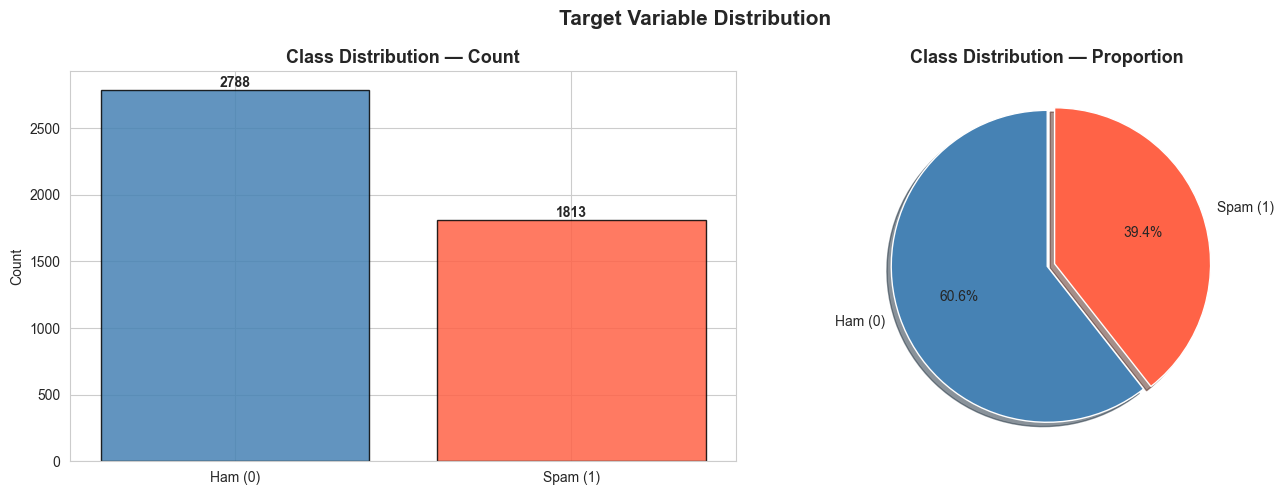

Ham : 2788  (60.6%)
Spam: 1813  (39.4%)
Imbalance ratio: 1.54:1


In [84]:
class_counts = df[TARGET].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Ham (0)', 'Spam (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Ham (0)', 'Spam (1)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05], shadow=True)
axes[1].set_title('Class Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Ham : {class_counts[0]}  ({class_counts[0]/len(df)*100:.1f}%)')
print(f'Spam: {class_counts[1]}  ({class_counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1')

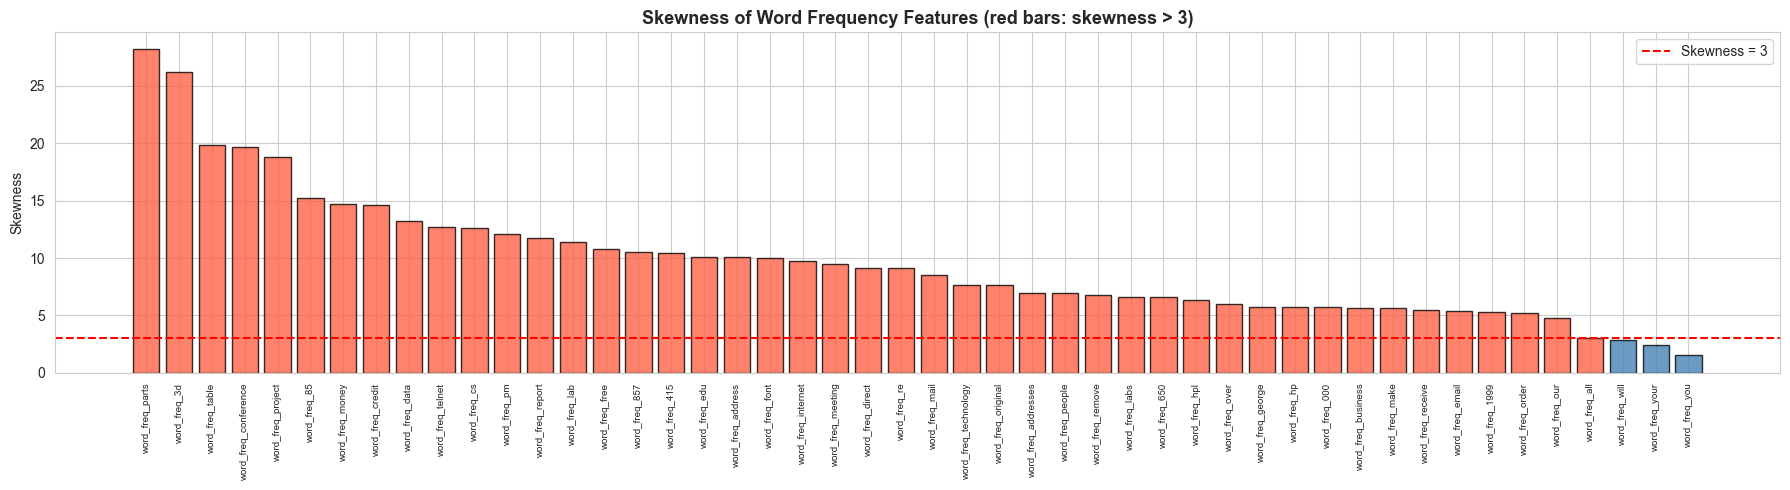

Highly skewed features (skewness > 3): 45
Average skewness across word features: 9.69


In [85]:
word_cols = [c for c in features if c.startswith('word_')]
skewness = df[word_cols].skew().sort_values(ascending=False)

plt.figure(figsize=(18, 5))
colors = ['tomato' if s > 3 else 'steelblue' for s in skewness.values]
plt.bar(range(len(skewness)), skewness.values, color=colors, edgecolor='black', alpha=0.8)
plt.xticks(range(len(skewness)), skewness.index, rotation=90, fontsize=7)
plt.axhline(y=3, color='red', linestyle='--', linewidth=1.5, label='Skewness = 3')
plt.title('Skewness of Word Frequency Features (red bars: skewness > 3)', fontsize=13, fontweight='bold')
plt.ylabel('Skewness')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Highly skewed features (skewness > 3): {(skewness > 3).sum()}')
print(f'Average skewness across word features: {skewness.mean():.2f}')

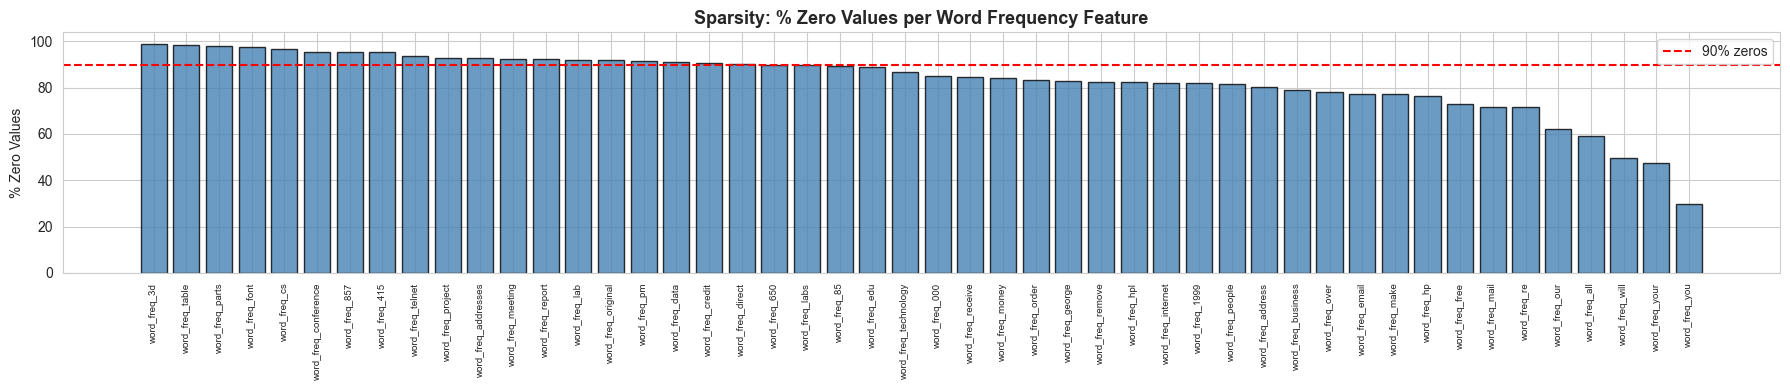

Features with >90% zeros: 19


In [86]:
zero_pct = (df[word_cols] == 0).mean().sort_values(ascending=False)
plt.figure(figsize=(18, 4))
plt.bar(range(len(zero_pct)), zero_pct.values * 100, color='steelblue', edgecolor='black', alpha=0.8)
plt.xticks(range(len(zero_pct)), zero_pct.index, rotation=90, fontsize=7)
plt.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% zeros')
plt.title('Sparsity: % Zero Values per Word Frequency Feature', fontsize=13, fontweight='bold')
plt.ylabel('% Zero Values')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Features with >90% zeros: {(zero_pct > 0.9).sum()}')

## 4. Data Cleaning

### 4.1 Duplicate Removal

In [87]:
n_before = df.shape[0]
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
n_after = df.shape[0]
print(f'Rows before deduplication : {n_before}')
print(f'Rows after  deduplication : {n_after}')
print(f'Duplicates removed        : {n_before - n_after}')

Rows before deduplication : 4601
Rows after  deduplication : 4210
Duplicates removed        : 391


### 4.2 Missing Values

In [88]:
null_counts = df.isnull().sum()
print(f'Total null values    : {null_counts.sum()}')
print(f'Features with nulls  : {(null_counts > 0).sum()}')
if null_counts.sum() == 0:
    print('No missing values detected — no imputation required.')

Total null values    : 0
Features with nulls  : 0
No missing values detected — no imputation required.


### 4.3 Outlier Analysis & Capping (Winsorization IQR × 3)

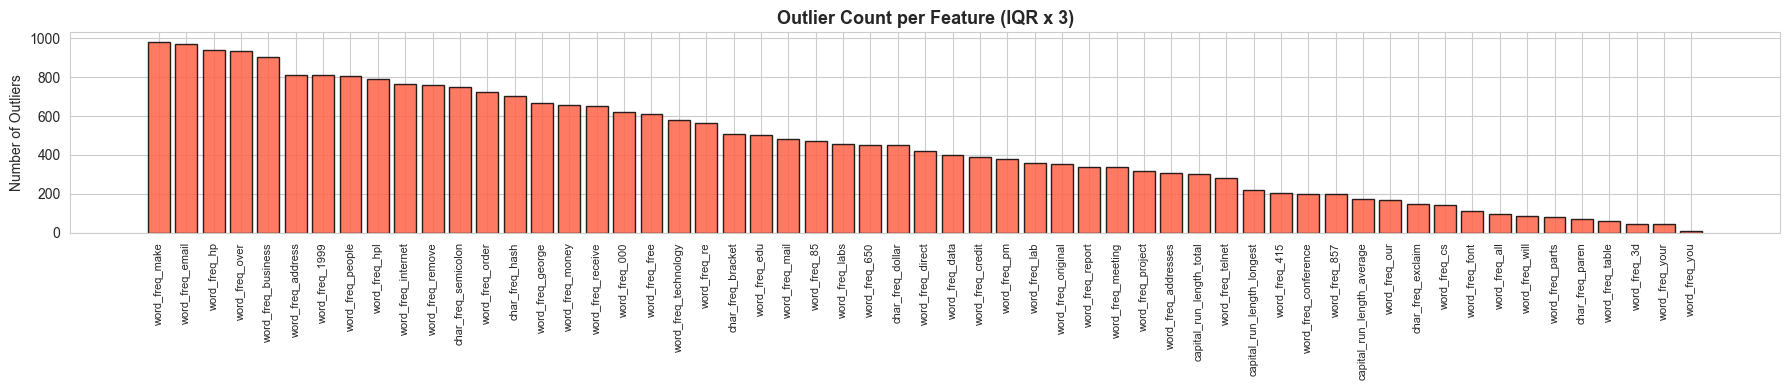

Features with outliers (IQR x 3): 57
Top 10:
word_freq_make        982
word_freq_email       972
word_freq_hp          939
word_freq_over        933
word_freq_business    906
word_freq_address     811
word_freq_1999        809
word_freq_people      806
word_freq_hpl         789
word_freq_internet    767


In [89]:
def count_outliers_iqr(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - factor * IQR) | (series > Q3 + factor * IQR)).sum()

outlier_counts = pd.Series({c: count_outliers_iqr(df[c]) for c in features})
outlier_counts = outlier_counts[outlier_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(18, 4))
plt.bar(range(len(outlier_counts)), outlier_counts.values, color='tomato', edgecolor='black', alpha=0.85)
plt.xticks(range(len(outlier_counts)), outlier_counts.index, rotation=90, fontsize=8)
plt.title('Outlier Count per Feature (IQR x 3)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Outliers')
plt.tight_layout()
plt.show()

print(f'Features with outliers (IQR x 3): {len(outlier_counts)}')
print(f'Top 10:')
print(outlier_counts.head(10).to_string())

In [90]:
print('Outlier capping assessment complete.')
print()
print('NOTE: Outlier capping is NOT applied to preserve genuine spam signals.')
print('  - capital_run_length_total  : up to 15,841 for spam emails')
print('  - capital_run_length_longest: up to  9,989 for spam emails')
print('  - word_freq_free etc.       : high values = strong spam indicator')
print('  Capping (IQR × 3) would destroy these discriminative extreme values.')
print('  The reference notebook uses raw values and achieves 96.3% XGBoost accuracy.')
print()
df_clean = df.copy()
print(f'Dataset shape (unchanged): {df_clean.shape}')

Outlier capping assessment complete.

NOTE: Outlier capping is NOT applied to preserve genuine spam signals.
  - capital_run_length_total  : up to 15,841 for spam emails
  - capital_run_length_longest: up to  9,989 for spam emails
  - word_freq_free etc.       : high values = strong spam indicator
  Capping (IQR × 3) would destroy these discriminative extreme values.
  The reference notebook uses raw values and achieves 96.3% XGBoost accuracy.

Dataset shape (unchanged): (4210, 58)


## 5. Feature Engineering

The Spambase dataset has well-known spam/ham word indicators based on the HP Labs domain context:
- **Spam words**: free, money, credit, 000, business, remove, order, internet, make, etc.
- **Ham words**: hp, hpl, george, 650 (HP area code), lab, labs, meeting, edu, etc.

We create aggregate cluster features, char frequency scores, capital-letter ratios, binary presence indicators, and apply log1p transformation to reduce skewness.

In [91]:
df_eng = df_clean.copy()

SPAM_WORDS = [
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you',
    'word_freq_credit', 'word_freq_your', 'word_freq_000', 'word_freq_money',
    'word_freq_make', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_addresses', 'word_freq_people',
    'word_freq_report', 'word_freq_font'
]

HAM_WORDS = [
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference'
]

df_eng['spam_word_score'] = df_eng[SPAM_WORDS].sum(axis=1)
df_eng['ham_word_score']  = df_eng[HAM_WORDS].sum(axis=1)
df_eng['spam_ham_ratio']  = (df_eng['spam_word_score'] + 1e-6) / (df_eng['ham_word_score'] + 1e-6)

print('Engineered: spam_word_score, ham_word_score, spam_ham_ratio')
for col in ['spam_word_score', 'ham_word_score', 'spam_ham_ratio']:
    spam_mean = df_eng.groupby(TARGET)[col].mean()
    print(f'  {col:25s} — Ham mean: {spam_mean[0]:.3f}, Spam mean: {spam_mean[1]:.3f}')

Engineered: spam_word_score, ham_word_score, spam_ham_ratio
  spam_word_score           — Ham mean: 2.618, Spam mean: 7.333
  ham_word_score            — Ham mean: 5.060, Spam mean: 0.365
  spam_ham_ratio            — Ham mean: 462988.441, Spam mean: 3699453.294


In [92]:
df_eng['char_spam_score'] = (df_eng['char_freq_exclaim'] +
                             df_eng['char_freq_dollar'] +
                             df_eng['char_freq_hash'])

df_eng['char_ham_score']  = (df_eng['char_freq_semicolon'] +
                             df_eng['char_freq_paren'])

df_eng['capital_ratio']   = (df_eng['capital_run_length_total'] /
                             (df_eng['capital_run_length_average'] + 1e-6))

print('Engineered: char_spam_score, char_ham_score, capital_ratio')
for col in ['char_spam_score', 'char_ham_score', 'capital_ratio']:
    spam_mean = df_eng.groupby(TARGET)[col].mean()
    print(f'  {col:25s} — Ham mean: {spam_mean[0]:.3f}, Spam mean: {spam_mean[1]:.3f}')

Engineered: char_spam_score, char_ham_score, capital_ratio
  char_spam_score           — Ham mean: 0.154, Spam mean: 0.779
  char_ham_score            — Ham mean: 0.222, Spam mean: 0.128
  capital_ratio             — Ham mean: 70.234, Spam mean: 99.139


In [93]:
KEY_WORDS_BINARY = SPAM_WORDS[:8] + HAM_WORDS[:6]
for col in KEY_WORDS_BINARY:
    new_name = col.replace('word_freq_', 'word_present_')
    df_eng[new_name] = (df_eng[col] > 0).astype(int)

all_word_cols = [c for c in features if c.startswith('word_')]
df_eng['word_diversity'] = (df_eng[all_word_cols] > 0).sum(axis=1)

presence_cols = [c for c in df_eng.columns if c.startswith('word_present_')]
print(f'Binary presence features added: {len(presence_cols)}')
print(f'word_diversity — Ham mean: {df_eng.groupby(TARGET)["word_diversity"].mean()[0]:.1f}, '
      f'Spam mean: {df_eng.groupby(TARGET)["word_diversity"].mean()[1]:.1f}')
print(f'\nSpam rate by word_present_free presence:')
print(df_eng.groupby('word_present_free')[TARGET].mean().round(3).to_string())

Binary presence features added: 14
word_diversity — Ham mean: 7.1, Spam mean: 10.1

Spam rate by word_present_free presence:
word_present_free
0    0.252
1    0.786


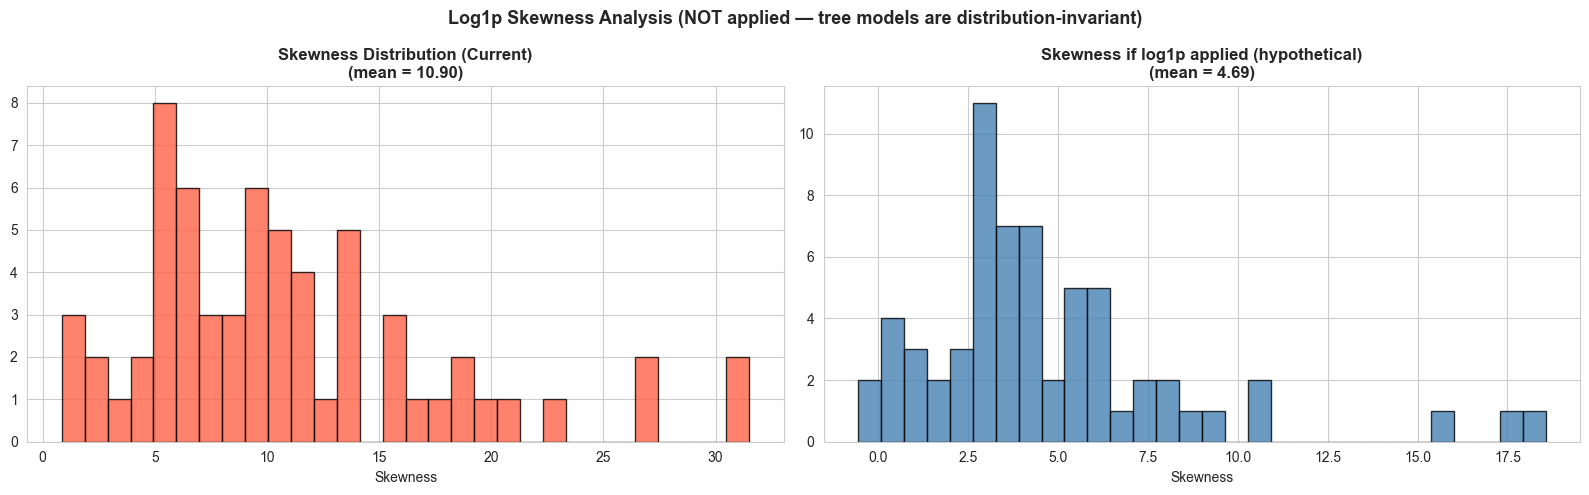

NOTE: log1p transformation is NOT applied.
  Current avg skewness      : 10.90
  After log1p (hypothetical): 4.69

Tree models (RF, XGB, GB) find split points regardless of skewness.
Extreme values (e.g. capital_run_length_total=15841) ARE the spam signal.
Log1p compresses those values and hurts tree model performance.

Dataset shape unchanged: (4210, 79)


In [94]:
LOG_COLS = (
    [c for c in df_eng.columns if c.startswith('word_freq_')] +
    [c for c in df_eng.columns if c.startswith('char_freq_')] +
    ['capital_run_length_average', 'capital_run_length_longest',
     'capital_run_length_total', 'spam_word_score', 'ham_word_score',
     'char_spam_score', 'char_ham_score', 'capital_ratio', 'word_diversity']
)
LOG_COLS = [c for c in LOG_COLS if c in df_eng.columns]

skew_before       = df_eng[LOG_COLS].skew()
skew_hypothetical = np.log1p(df_eng[LOG_COLS]).skew()
avg_skew_before   = skew_before.mean()
avg_skew_after    = skew_hypothetical.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(skew_before.values, bins=30, color='tomato', edgecolor='black', alpha=0.8)
axes[0].set_title(f'Skewness Distribution (Current)\n(mean = {avg_skew_before:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Skewness')
axes[1].hist(skew_hypothetical.values, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title(f'Skewness if log1p applied (hypothetical)\n(mean = {avg_skew_after:.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Skewness')
plt.suptitle('Log1p Skewness Analysis (NOT applied — tree models are distribution-invariant)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('NOTE: log1p transformation is NOT applied.')
print(f'  Current avg skewness      : {avg_skew_before:.2f}')
print(f'  After log1p (hypothetical): {avg_skew_after:.2f}')
print()
print('Tree models (RF, XGB, GB) find split points regardless of skewness.')
print('Extreme values (e.g. capital_run_length_total=15841) ARE the spam signal.')
print('Log1p compresses those values and hurts tree model performance.')
print(f'\nDataset shape unchanged: {df_eng.shape}')

## 6. Encoding Analysis

**All 57 original Spambase features are continuous numerical attributes** (float64 / int64):
- 48 `word_freq_*` — percentage of words matching a keyword (continuous, [0, 100])
- 6 `char_freq_*` — percentage of characters matching a special character (continuous, [0, 100])
- 3 `capital_run_length_*` — capital letter run statistics (continuous/integer)

There are **no categorical, ordinal, or nominal features** requiring One-Hot, Ordinal, or Target encoding.

**Binary presence features** (`word_present_*`) created during Feature Engineering are already 0/1 integer-encoded.

In [95]:
cat_features = df_eng.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical/object features found: {len(cat_features)}')
if not cat_features:
    print('All features are numerical — no One-Hot / Ordinal / Label encoding required.')

dtype_summary = df_eng.dtypes.value_counts()
print(f'\nDtype distribution:')
print(dtype_summary.to_string())

presence_cols = [c for c in df_eng.columns if c.startswith('word_present_')]
print(f'\nBinary presence features (0/1 encoded): {len(presence_cols)}')
print(presence_cols)

Categorical/object features found: 0
All features are numerical — no One-Hot / Ordinal / Label encoding required.

Dtype distribution:
float64    61
int64      18

Binary presence features (0/1 encoded): 14
['word_present_free', 'word_present_business', 'word_present_email', 'word_present_you', 'word_present_credit', 'word_present_your', 'word_present_000', 'word_present_money', 'word_present_hp', 'word_present_hpl', 'word_present_george', 'word_present_650', 'word_present_lab', 'word_present_labs']


## 7. Correlation Analysis & Feature Selection

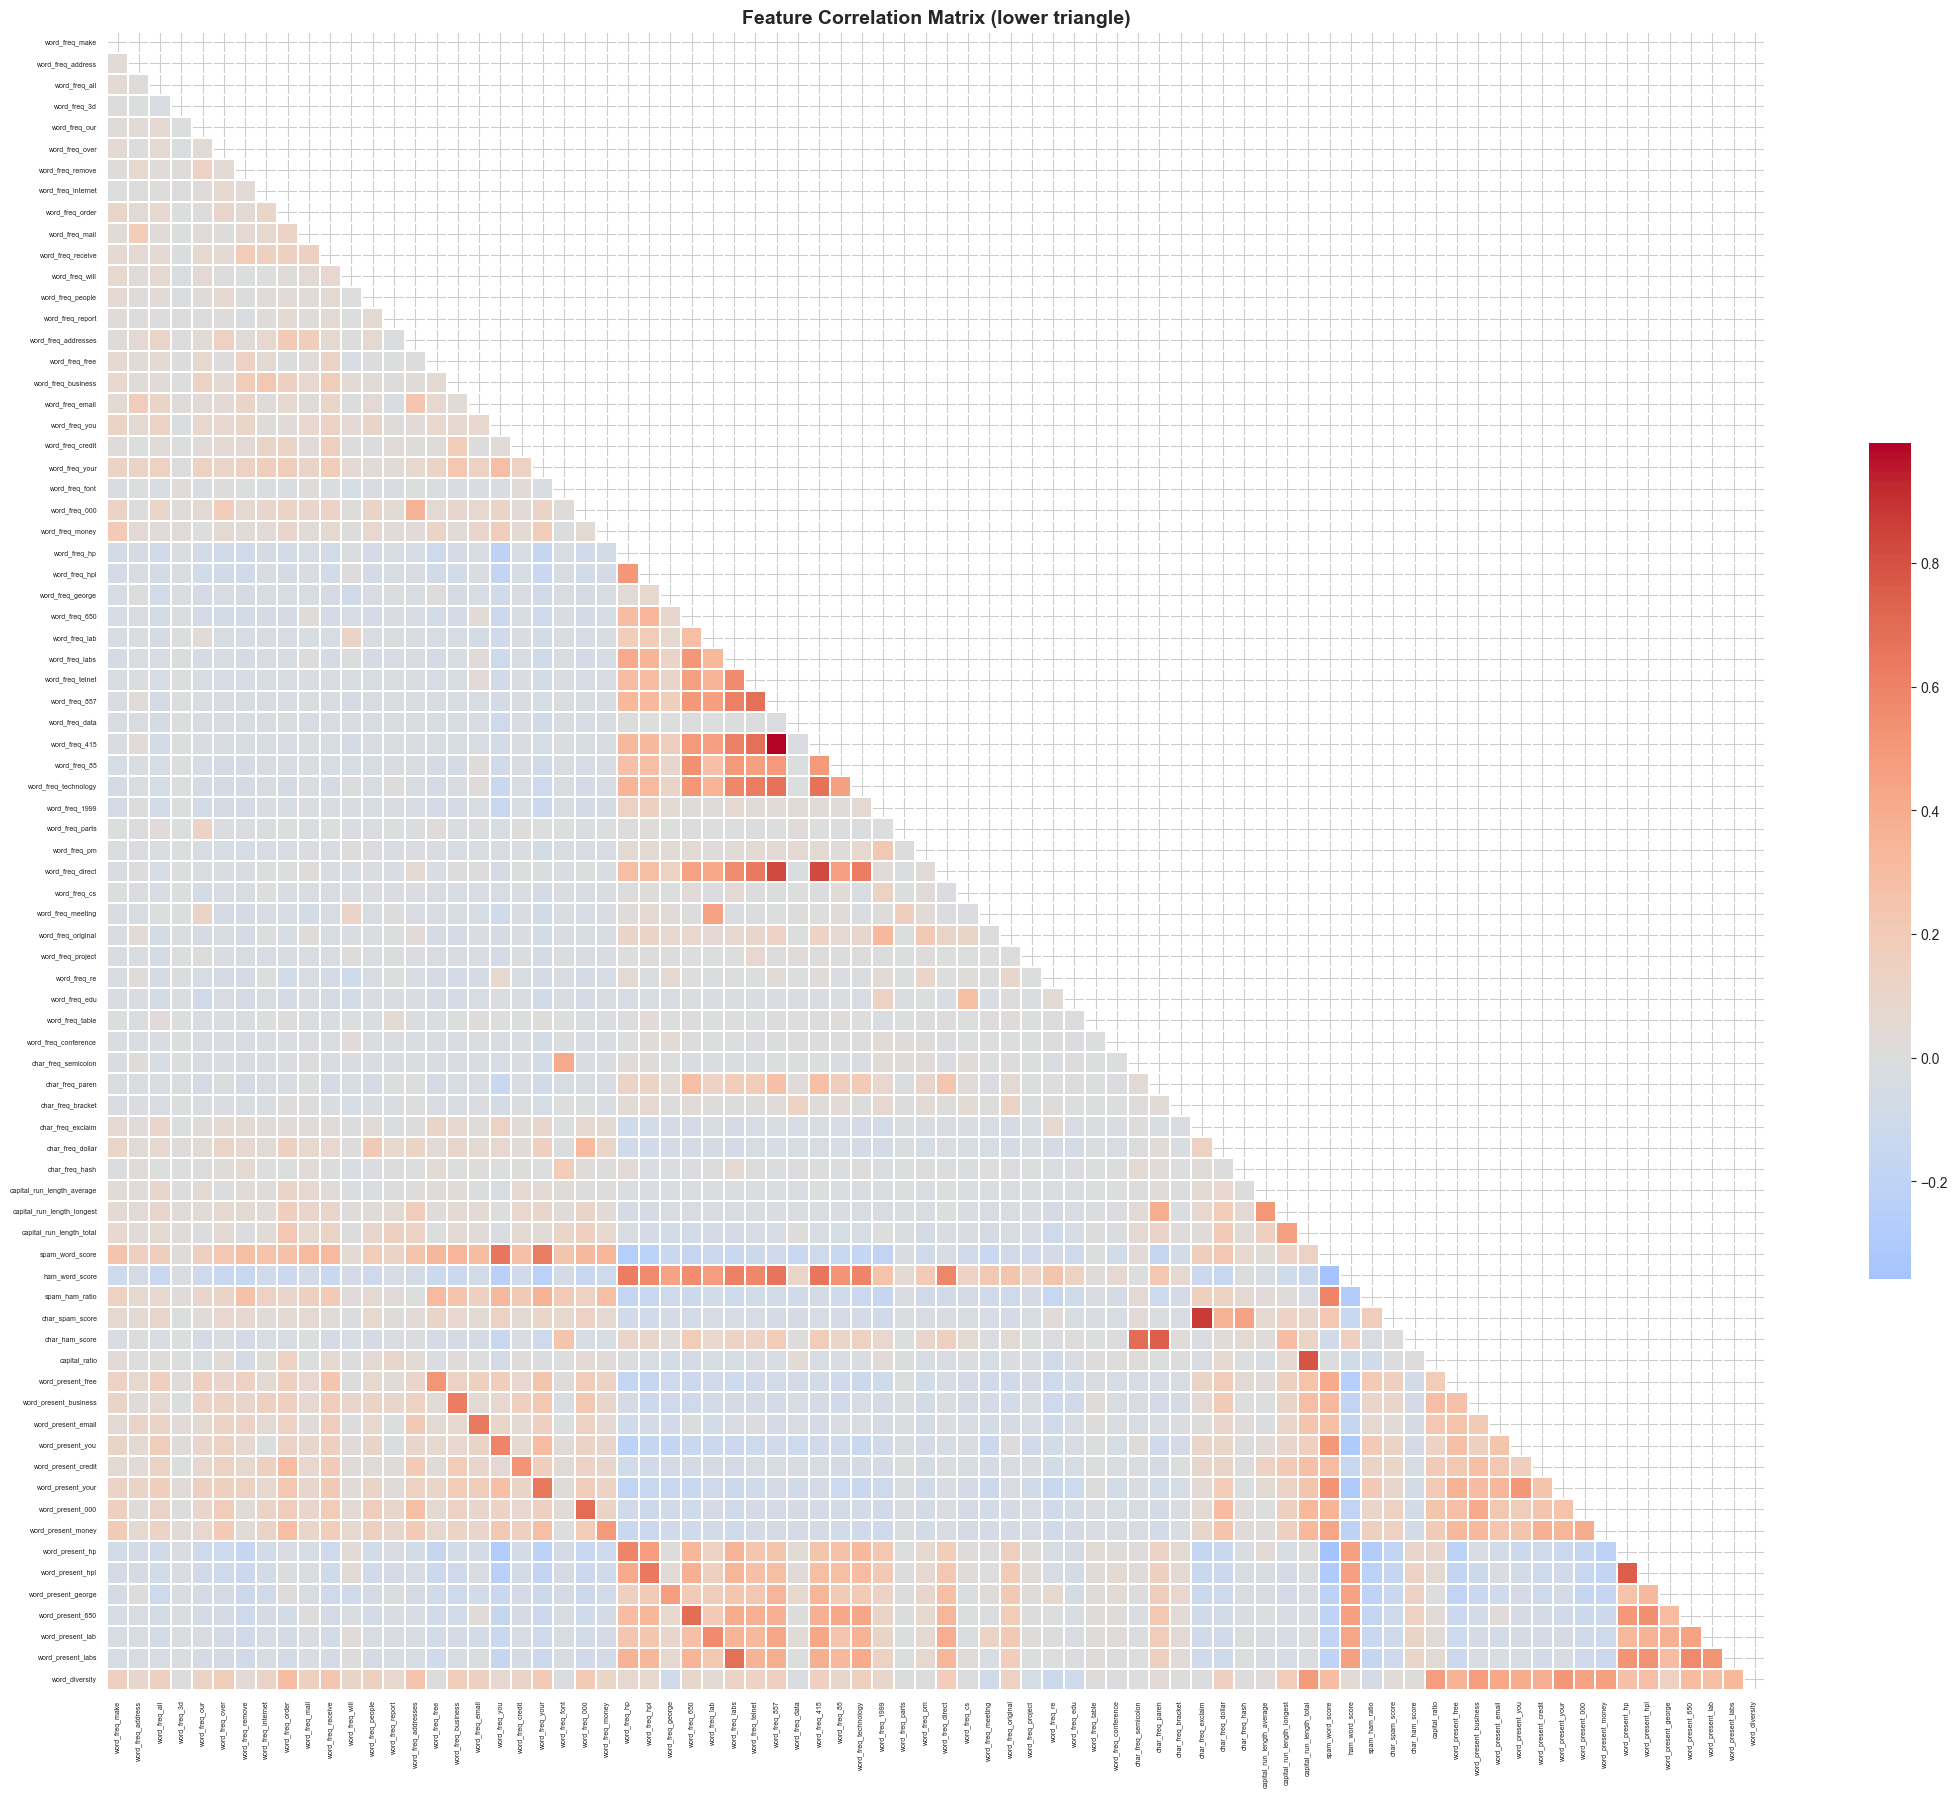

In [96]:
corr_features = [c for c in df_eng.columns if c != TARGET]
corr_matrix = df_eng[corr_features].corr()

plt.figure(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.2, cbar_kws={'shrink': 0.5},
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=5)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

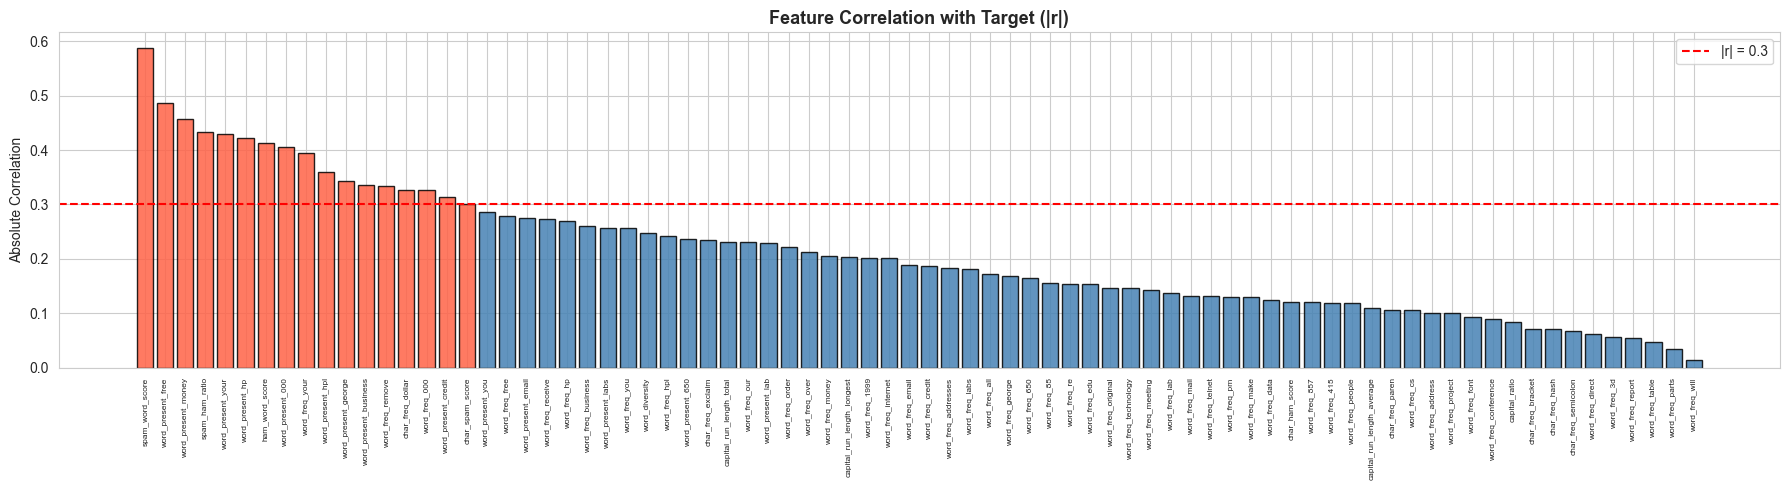

Top 15 features correlated with spam:
spam_word_score          0.587
word_present_free        0.487
word_present_money       0.457
spam_ham_ratio           0.433
word_present_your        0.429
word_present_hp          0.422
ham_word_score           0.414
word_present_000         0.406
word_freq_your           0.394
word_present_hpl         0.360
word_present_george      0.343
word_present_business    0.335
word_freq_remove         0.334
char_freq_dollar         0.327
word_freq_000            0.326


In [97]:
corr_with_target = df_eng[corr_features + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

plt.figure(figsize=(18, 5))
colors = ['tomato' if v > 0.3 else 'steelblue' for v in corr_with_target.values]
plt.bar(range(len(corr_with_target)), corr_with_target.values, color=colors, edgecolor='black', alpha=0.85)
plt.xticks(range(len(corr_with_target)), corr_with_target.index, rotation=90, fontsize=6)
plt.axhline(y=0.3, color='red', linestyle='--', linewidth=1.5, label='|r| = 0.3')
plt.title('Feature Correlation with Target (|r|)', fontsize=13, fontweight='bold')
plt.ylabel('Absolute Correlation')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 15 features correlated with spam:')
print(corr_with_target.head(15).round(3).to_string())

In [98]:
CORR_THRESHOLD = 0.85
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

would_drop_corr = set()
for col in upper_tri.columns:
    partners = upper_tri.index[upper_tri[col].abs() > CORR_THRESHOLD].tolist()
    for partner in partners:
        col_corr_target     = corr_with_target.get(col, 0)
        partner_corr_target = corr_with_target.get(partner, 0)
        if col_corr_target < partner_corr_target:
            would_drop_corr.add(col)
        else:
            would_drop_corr.add(partner)

print(f'Features with |r| > {CORR_THRESHOLD} (would be dropped): {len(would_drop_corr)}')
print(sorted(would_drop_corr))
print()
print('NOTE: Features are KEPT — tree models (RF, XGB, GB) handle correlated features')
print('natively. Dropping correlated features significantly hurts their performance.')
print('Correlation analysis retained for insight and reporting only.')
print(f'\nDataset shape unchanged: {df_eng.shape}')

Features with |r| > 0.85 (would be dropped): 2
['char_freq_exclaim', 'word_freq_415']

NOTE: Features are KEPT — tree models (RF, XGB, GB) handle correlated features
natively. Dropping correlated features significantly hurts their performance.
Correlation analysis retained for insight and reporting only.

Dataset shape unchanged: (4210, 79)


## 8. VIF Analysis — Multicollinearity Reduction

Top 20 features by VIF:
             Feature  VIF
      word_freq_make  inf
      word_freq_labs  inf
       word_freq_857  inf
      word_freq_data  inf
       word_freq_415  inf
        word_freq_85  inf
word_freq_technology  inf
      word_freq_1999  inf
     word_freq_parts  inf
        word_freq_pm  inf
        word_freq_cs  inf
   word_freq_meeting  inf
  word_freq_original  inf
   word_freq_project  inf
        word_freq_re  inf
       word_freq_edu  inf
     word_freq_table  inf
word_freq_conference  inf
 char_freq_semicolon  inf
     char_freq_paren  inf


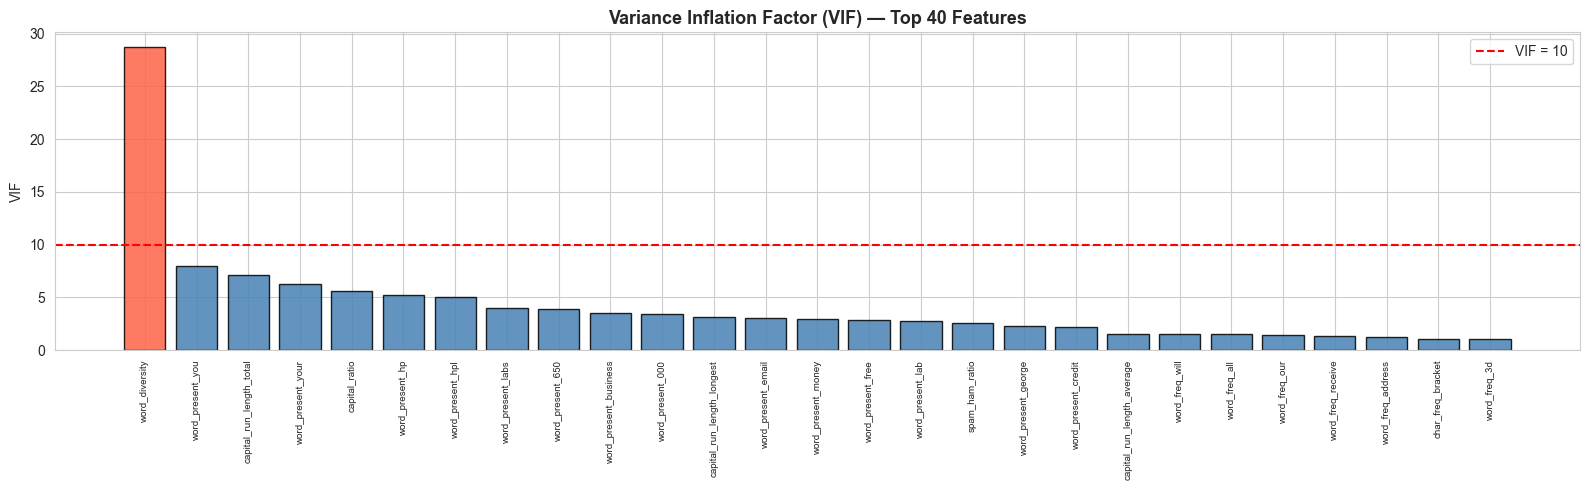

In [99]:
X_vif = df_eng.drop(columns=[TARGET]).select_dtypes(include=[np.number]).copy()
X_vif_vals = X_vif.values.astype(float)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif_vals, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('Top 20 features by VIF:')
print(vif_data.head(20).to_string(index=False))

plot_data = vif_data[vif_data['VIF'] < 500].head(40)
plt.figure(figsize=(16, 5))
colors = ['tomato' if v > 10 else 'steelblue' for v in plot_data['VIF']]
plt.bar(range(len(plot_data)), plot_data['VIF'], color=colors, edgecolor='black', alpha=0.85)
plt.xticks(range(len(plot_data)), plot_data['Feature'], rotation=90, fontsize=7)
plt.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='VIF = 10')
plt.title('Variance Inflation Factor (VIF) — Top 40 Features', fontsize=13, fontweight='bold')
plt.ylabel('VIF')
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
VIF_THRESHOLD = 10
high_vif_cols = vif_data[vif_data['VIF'] > VIF_THRESHOLD]['Feature'].tolist()

print(f'Features with VIF > {VIF_THRESHOLD}: {len(high_vif_cols)}')
print(high_vif_cols)
print()
print('NOTE: Features are KEPT — VIF analysis is for reporting insight only.')
print('Tree models (RF, XGB, GB) are immune to multicollinearity.')
print('Dropping high-VIF features is only appropriate for linear regression.')
print(f'\nDataset shape unchanged: {df_eng.shape}')

Features with VIF > 10: 52
['word_freq_make', 'word_freq_labs', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_semicolon', 'char_freq_paren', 'char_freq_exclaim', 'char_freq_dollar', 'char_freq_hash', 'spam_word_score', 'ham_word_score', 'char_spam_score', 'char_ham_score', 'word_freq_telnet', 'word_freq_direct', 'word_freq_lab', 'word_freq_email', 'word_freq_over', 'word_freq_650', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_remove', 'word_freq_you', 'word_freq_money', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_george', 'word_freq_hpl', 'word_freq_000', 'word_freq_hp', 'word

## 8b. RFE — Recursive Feature Elimination

Borrowed from the reference notebook technique. We use **Recursive Feature Elimination (RFE)** with Logistic Regression as the base estimator to find the optimal number of features, tracking the weighted F1 score as features are progressively removed.

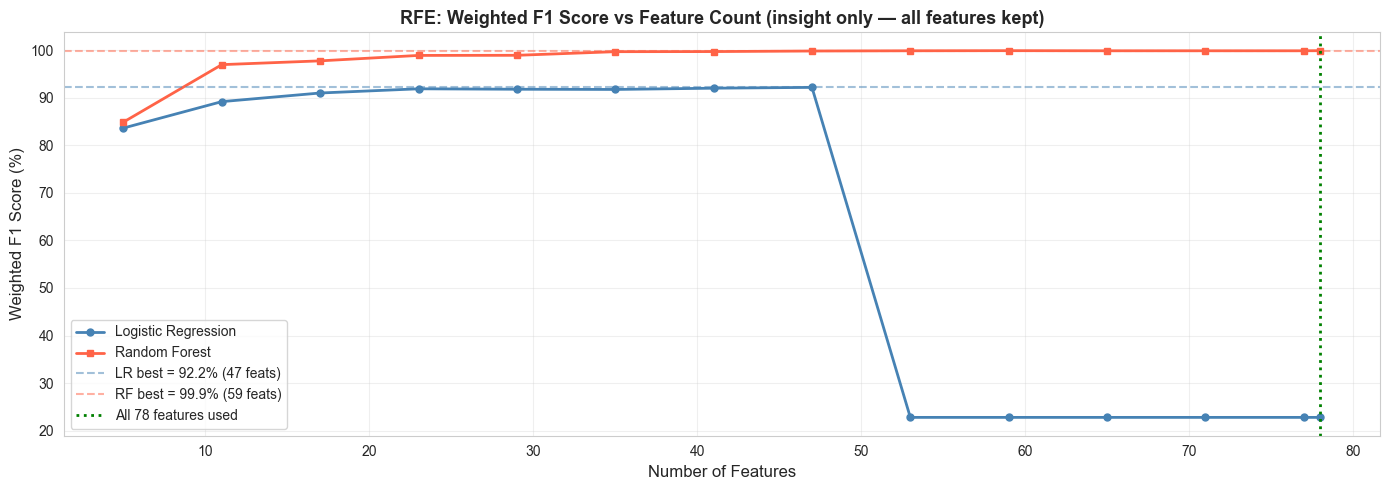

Total features: 78 | RFE optimal (RF): 59
RFE is for analysis/insight only — all features retained for model training.


In [101]:
X_rfe_all = df_eng.drop(columns=[TARGET])
y_rfe_all = df_eng[TARGET]

total_feats = X_rfe_all.shape[1]
step = max(1, total_feats // 12)
n_range = list(range(5, total_feats + 1, step))
if total_feats not in n_range:
    n_range.append(total_feats)

lr_rfe_base = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)
from sklearn.ensemble import RandomForestClassifier as _RFC
rf_rfe_base = _RFC(n_estimators=50, random_state=42, n_jobs=-1)

scores_lr_rfe = []
scores_rf_rfe = []

for n in n_range:
    rfe = RFE(lr_rfe_base, n_features_to_select=n)
    rfe.fit(X_rfe_all, y_rfe_all)
    X_sub = X_rfe_all.loc[:, rfe.support_]
    s_lr = f1_score(y_rfe_all, lr_rfe_base.fit(X_sub, y_rfe_all).predict(X_sub), average='weighted') * 100
    s_rf = f1_score(y_rfe_all, rf_rfe_base.fit(X_sub, y_rfe_all).predict(X_sub), average='weighted') * 100
    scores_lr_rfe.append(s_lr)
    scores_rf_rfe.append(s_rf)

plt.figure(figsize=(14, 5))
plt.plot(n_range, scores_lr_rfe, 'o-', color='steelblue', lw=2, ms=5, label='Logistic Regression')
plt.plot(n_range, scores_rf_rfe, 's-', color='tomato',    lw=2, ms=5, label='Random Forest')
plt.axhline(y=max(scores_lr_rfe), color='steelblue', ls='--', alpha=0.5,
            label=f'LR best = {max(scores_lr_rfe):.1f}% ({n_range[scores_lr_rfe.index(max(scores_lr_rfe))]} feats)')
plt.axhline(y=max(scores_rf_rfe), color='tomato', ls='--', alpha=0.5,
            label=f'RF best = {max(scores_rf_rfe):.1f}% ({n_range[scores_rf_rfe.index(max(scores_rf_rfe))]} feats)')
plt.axvline(x=total_feats, color='green', ls=':', lw=2, label=f'All {total_feats} features used')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Weighted F1 Score (%)', fontsize=12)
plt.title('RFE: Weighted F1 Score vs Feature Count (insight only — all features kept)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_n_rfe = n_range[scores_rf_rfe.index(max(scores_rf_rfe))]
print(f'Total features: {total_feats} | RFE optimal (RF): {best_n_rfe}')
print('RFE is for analysis/insight only — all features retained for model training.')

In [102]:
rfe_selector = RFE(LogisticRegression(solver='liblinear', max_iter=2000, random_state=42),
                   n_features_to_select=best_n_rfe)
rfe_selector.fit(X_rfe_all, y_rfe_all)

rfe_selected = X_rfe_all.columns[rfe_selector.support_].tolist()
rfe_dropped  = [c for c in X_rfe_all.columns if c not in rfe_selected]

print(f'RFE insight — top {best_n_rfe} features ranked by LR (for reporting):')
print(rfe_selected[:20], '...' if len(rfe_selected) > 20 else '')
print()
print(f'Features that would be dropped if RFE were applied: {len(rfe_dropped)}')
print()
print('All features RETAINED — this step is analysis-only.')
print(f'Dataset shape: {df_eng.shape}')

RFE insight — top 59 features ranked by LR (for reporting):
['word_freq_3d', 'word_freq_remove', 'word_freq_internet', 'word_freq_will', 'word_freq_free', 'word_freq_business', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data'] ...

Features that would be dropped if RFE were applied: 19

All features RETAINED — this step is analysis-only.
Dataset shape: (4210, 79)


## 9. SMOTE — Class Balancing

In [103]:
X = df_eng.drop(columns=[TARGET])
y = df_eng[TARGET]

print('Class distribution BEFORE SMOTE:')
print(y.value_counts().to_string())
print(f'Ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1')

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f'\nClass distribution AFTER SMOTE:')
print(pd.Series(y_res).value_counts().to_string())
print(f'Samples: {X.shape[0]} -> {X_res.shape[0]} (added {X_res.shape[0] - X.shape[0]} synthetic)')

Class distribution BEFORE SMOTE:
spam
0    2531
1    1679
Ratio: 1.51:1

Class distribution AFTER SMOTE:
spam
1    2531
0    2531
Samples: 4210 -> 5062 (added 852 synthetic)


## 10. Feature Scaling — RobustScaler

`RobustScaler` uses **median** and **IQR** instead of mean/std, making it significantly more robust to the heavy-tailed
word frequency distributions present in this dataset compared to StandardScaler.

In [104]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_res)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_res.columns)
X_scaled_df[TARGET] = y_res.values

print('RobustScaler applied.')
print(f'Final dataset shape: {X_scaled_df.shape}')
print(f'\nSample statistics after scaling (first 8 features):')
display(X_scaled_df.drop(columns=[TARGET]).iloc[:, :8].describe().round(3))

RobustScaler applied.
Final dataset shape: (5062, 79)

Sample statistics after scaling (first 8 features):


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet
count,5062.000,5062.000,5062.000,5062.000,5062.000,5062.000,5062.000,5062.000
mean,1.614,0.123,0.637,0.079,0.726,2.154,5.326,0.119
std,4.254,0.436,1.035,1.439,1.376,5.487,15.174,0.403
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,1.000,0.000,1.000,0.000,1.000,1.000,1.000,0.000
max,65.434,14.280,10.503,42.810,20.000,117.600,265.908,11.110


## 11. Save Preprocessed Data

In [105]:
OUTPUT_PATH = 'preprocessed_data.csv'
X_scaled_df.to_csv(OUTPUT_PATH, index=False)
print(f'Preprocessed data saved to: {OUTPUT_PATH}')
print(f'Shape: {X_scaled_df.shape}')
print(f'\nAll columns ({len(X_scaled_df.columns)}):')
print(list(X_scaled_df.columns))

Preprocessed data saved to: preprocessed_data.csv
Shape: (5062, 79)

All columns (79):
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq

In [106]:
print('=' * 70)
print('              DATA PREPARATION SUMMARY')
print('=' * 70)
print(f'  Original dataset            : 4601 rows, 57 features')
print(f'  After deduplication         : {df.shape[0]} rows')
print(f'  Outlier capping             : NOT applied (extreme values = spam signal)')
print(f'  Log1p transform             : NOT applied (trees are distribution-invariant)')
print(f'  Features engineered (+added):')
print(f'      spam_word_score, ham_word_score, spam_ham_ratio')
print(f'      char_spam_score, char_ham_score, capital_ratio')
print(f'      word_present_* (14 binary), word_diversity')
print(f'  Encoding                    : All numerical — no encoding required')
print(f'  Correlation analysis        : Visualisation only — NO features dropped')
print(f'  VIF analysis                : Visualisation only — NO features dropped')
print(f'  RFE analysis                : Visualisation only — NO features dropped')
print(f'  After SMOTE                 : {X_res.shape[0]} rows (balanced 50/50)')
print(f'  Scaling                     : RobustScaler (median + IQR)')
print(f'  Final feature count         : {X_scaled_df.shape[1] - 1} features')
print(f'  Final dataset               : {X_scaled_df.shape}')
print(f'  Saved to                    : preprocessed_data.csv')
print('=' * 70)
print()
print('Baselines to beat (reference notebook — raw values, StandardScaler, no engineering):')
baseline_ref = {
    'XGBoost': 96.3, 'Random Forest': 96.2, 'Gradient Boosting': 95.2,
    'SVM': 94.5, 'KNN': 94.0, 'Logistic Regression': 93.1,
    'Naive Bayes': 90.7, 'Decision Tree': 90.3
}
for m, acc in sorted(baseline_ref.items(), key=lambda x: -x[1]):
    print(f'  {m:25s}: {acc:.1f}%')
print(f'\n  --> TARGET: beat XGBoost 96.3%  (our pipeline: raw values + {X_scaled_df.shape[1]-1} features)')

              DATA PREPARATION SUMMARY
  Original dataset            : 4601 rows, 57 features
  After deduplication         : 4210 rows
  Outlier capping             : NOT applied (extreme values = spam signal)
  Log1p transform             : NOT applied (trees are distribution-invariant)
  Features engineered (+added):
      spam_word_score, ham_word_score, spam_ham_ratio
      char_spam_score, char_ham_score, capital_ratio
      word_present_* (14 binary), word_diversity
  Encoding                    : All numerical — no encoding required
  Correlation analysis        : Visualisation only — NO features dropped
  VIF analysis                : Visualisation only — NO features dropped
  RFE analysis                : Visualisation only — NO features dropped
  After SMOTE                 : 5062 rows (balanced 50/50)
  Scaling                     : RobustScaler (median + IQR)
  Final feature count         : 78 features
  Final dataset               : (5062, 79)
  Saved to                  